## Exercise 3 — **Nonlinear problems**

The goal of this exercise is to consolidate:
- Nonlinear processes
- Advection and diffusion

The goal of this exercise is to program two short 1D codes to experiment with nonlinear processes, namely nonlinear diffusion and advection in order to reproduce the animations displayed in the [nonlinear equations section](#nonlinear-equations) of the lecture 2.

### Task 1

Referring to the [nonlinear equations section](#nonlinear_equations) in lecture 2, implement the nonlinear power-law type parabolic PDE in 1D:

$$
\frac{\partial C}{\partial t} - D\frac{\partial^2 C^n}{\partial x^2} = 0
$$

Use one of your previous scripts or the [`l2_diffusion_1D.jl`](https://github.com/eth-vaw-glaciology/course-101-0250-00/blob/main/scripts/) to get you started. Use the following parameters:

```julia
# physics
lx   = 20.0
dc   = 1.0
n    = 4
# numerics
nx   = 200
nvis = 50
# derived numerics
dx   = lx/nx
dt   = dx^2/dc/10
nt   = nx^2 ÷ 5
xc   = LinRange(dx/2,lx-dx/2,nx)
```
and initialising your quantity to diffuse as `0.5cos(9π*xc/lx)+0.5`.

Make sure your code reproduces the animation from the course (alternatively, provide 5 snapshot-plots of the simulation evolution).

nt = 8000


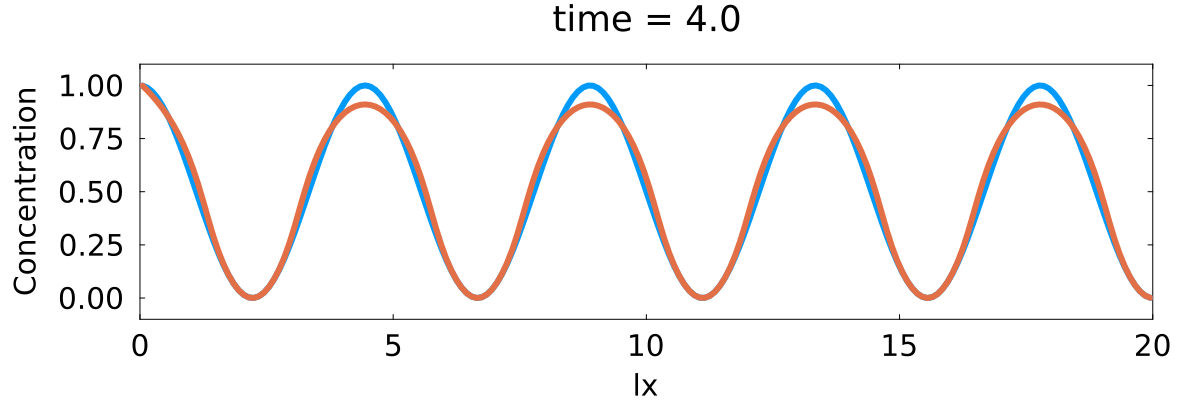

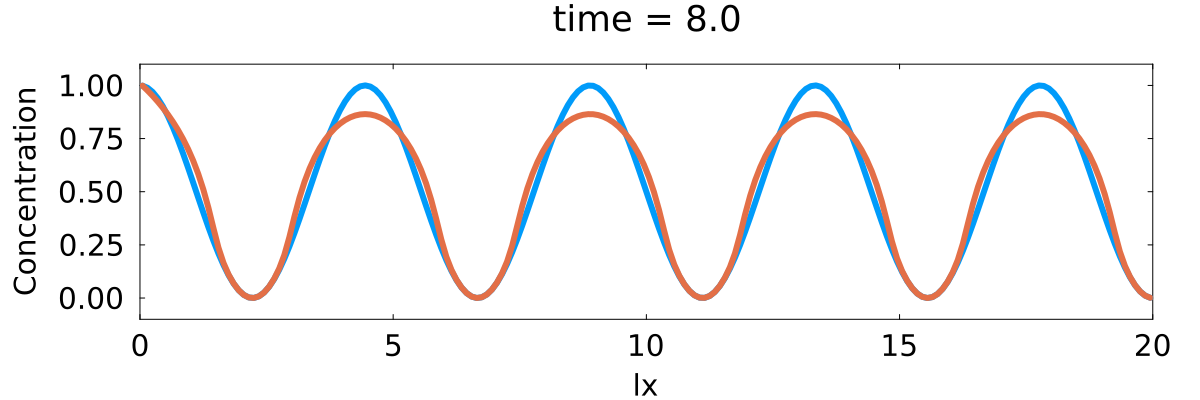

In [13]:
using Plots, Plots.Measures
default(size=(1200, 400), framestyle=:box, label=false, grid=false, margin=10mm, lw=6, labelfontsize=20, tickfontsize=20, titlefontsize=24)

@views function nonlinpower()
    # physics
    lx   = 20.0
    dc   = 1.0
    n    = 4
    
    # numerics
    nx   = 200
    nvis = 50
    
    # derived numerics
    dx   = lx/nx
    dt   = dx^2/dc/10
    nt   = nx^2 ÷ 5
    xc   = LinRange(dx/2,lx-dx/2,nx)

    C    = @. 0.5cos(9π*xc/lx)+0.5
    C_1  = copy(C)

    @show nt

    for it in 1:nt+1

        C[2:nx-1] .+= dt * dc .* diff(diff(C.^n))
        
        if it % 4_000 == 0
            display(plot(xc, [C_1, C]; xlims=(0, lx), ylims=(-0.1, 1.1),
                 xlabel="lx", ylabel="Concentration",
                 title="time = $(round(it*dt,digits=1))"))
        end
    end
end

nonlinpower()

### Task 2

Referring to the [nonlinear equations section](#nonlinear_equations) in lecture 2, implement the nonlinear advection _inviscid Burgers'_ equation in 1D:

$$
\frac{\partial C}{\partial t} + v_x \frac{\partial C^n}{\partial x} = 0
$$

Use one of your previous scripts or the [`diffusion_1D.jl`](https://github.com/eth-vaw-glaciology/course-101-0250-00/blob/main/scripts/) to get you started. Use the following parameters:

```julia
# physics
lx   = 20.0
vx   = 1.0
n    = 2
# numerics
nx   = 1000
nvis = 15
# derived numerics
dx   = lx/nx
dt   = dx/abs(vx)/2
nt   = 2nx
xc   = LinRange(dx/2,lx-dx/2,nx)
```
As initial condition, define a Gaussian profile of the quantity $C$ of amplitude and standard deviation equal to 1, located at `lx/4`.

In the time-loop, include a condition that would change de direction of the velocity `vx` at time `ttot/2`.

Make sure your code reproduces the animation from the course (alternatively, provide 5 snapshot-plots of the simulation evolution).

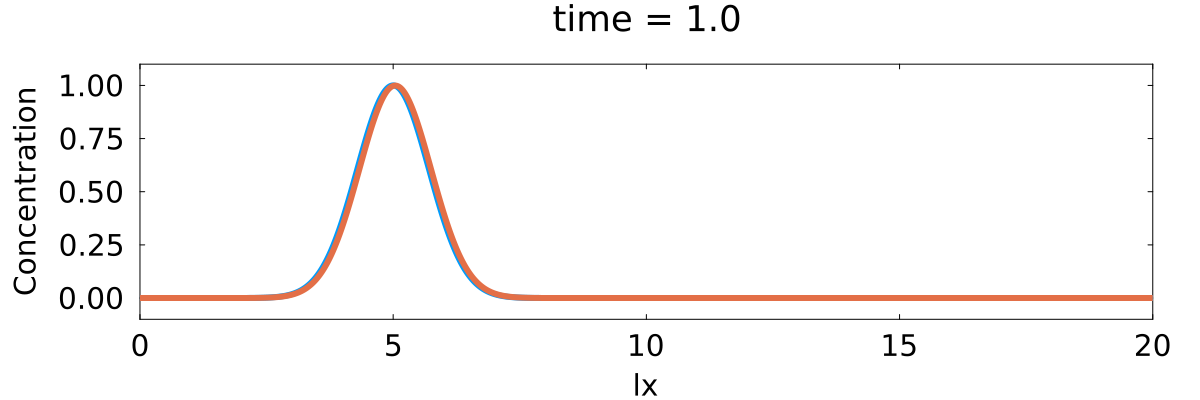

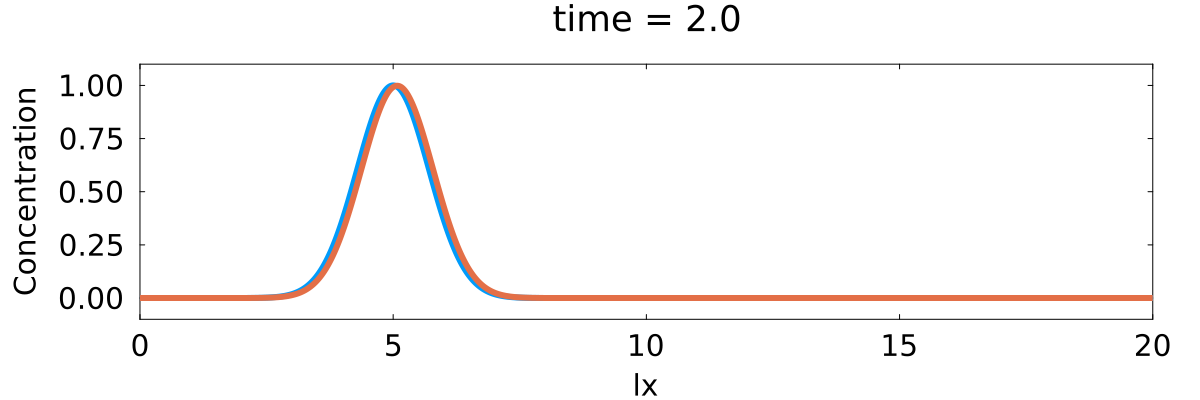

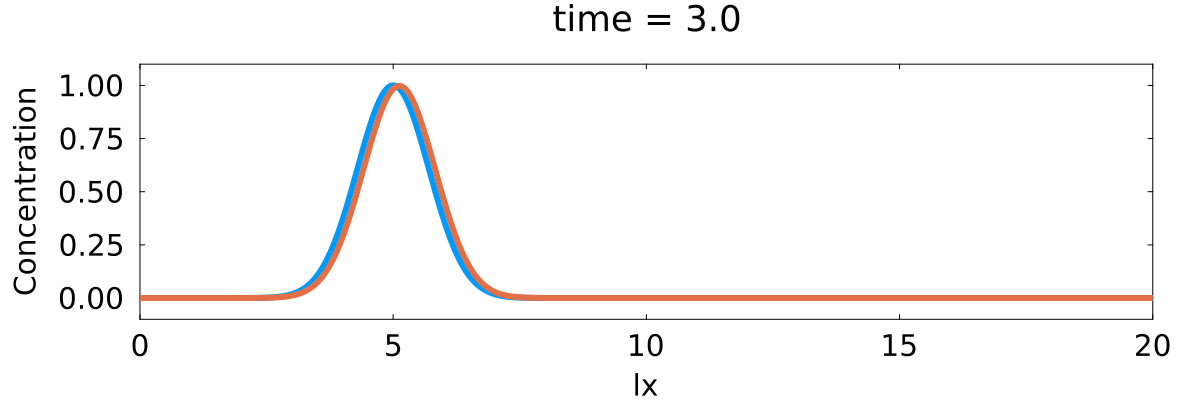

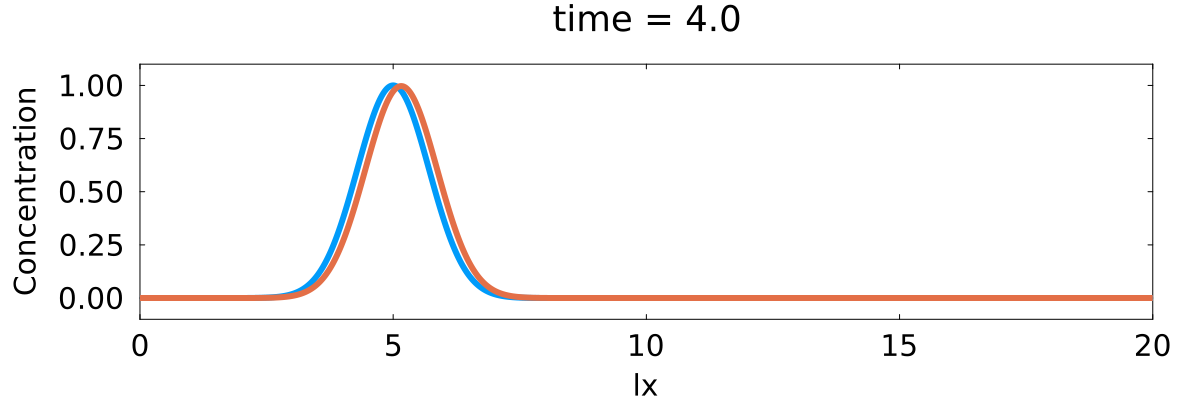

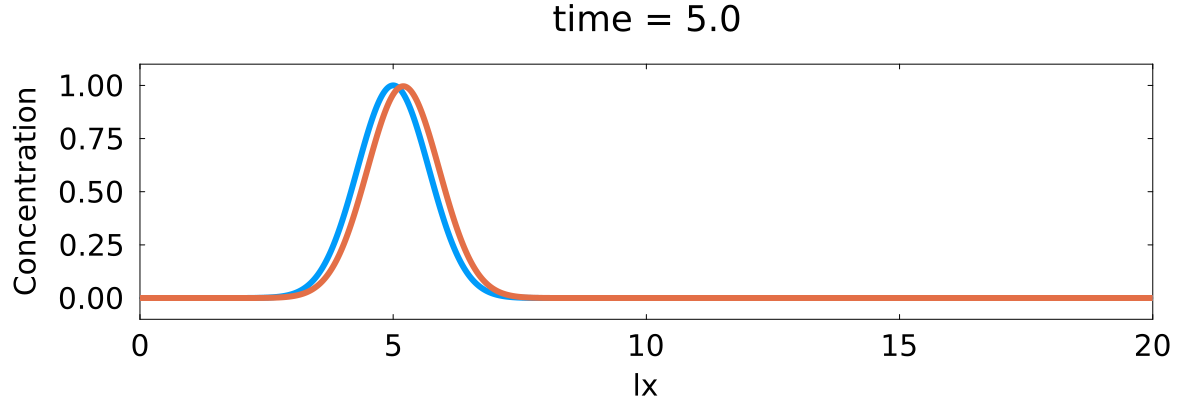

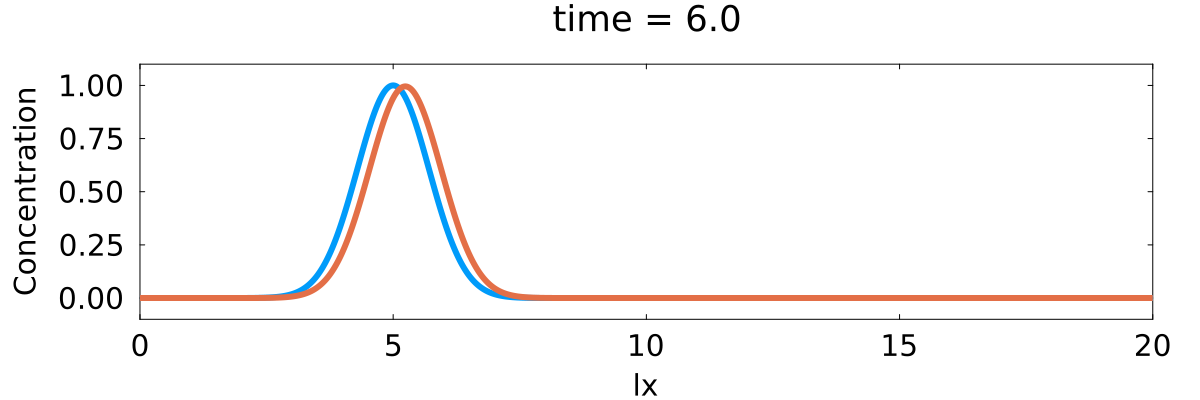

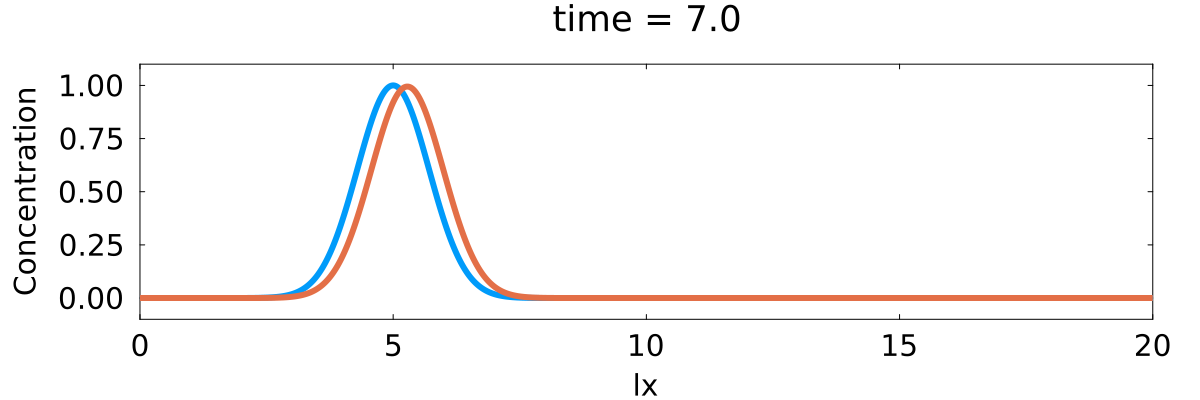

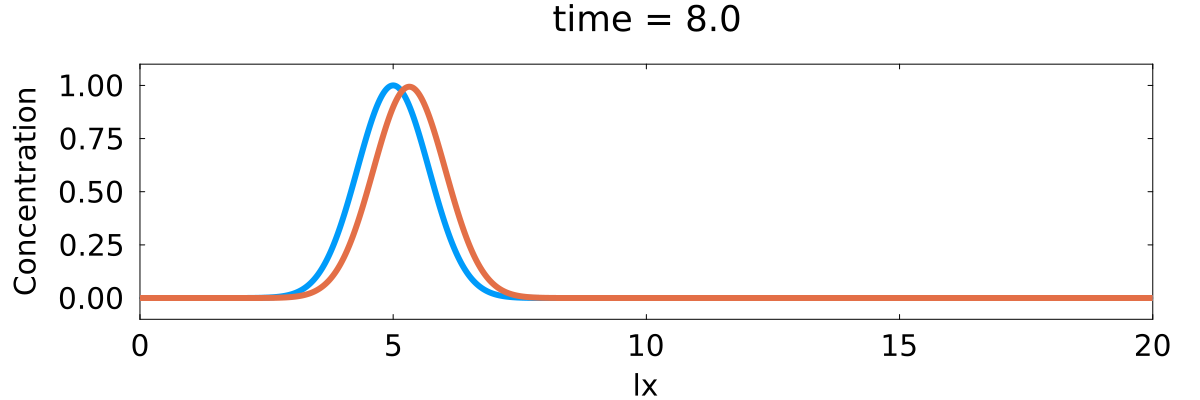

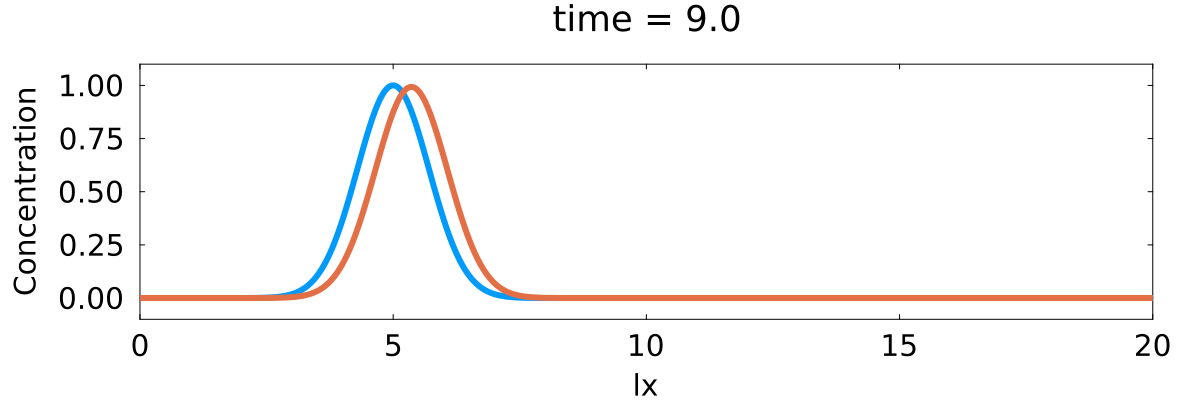

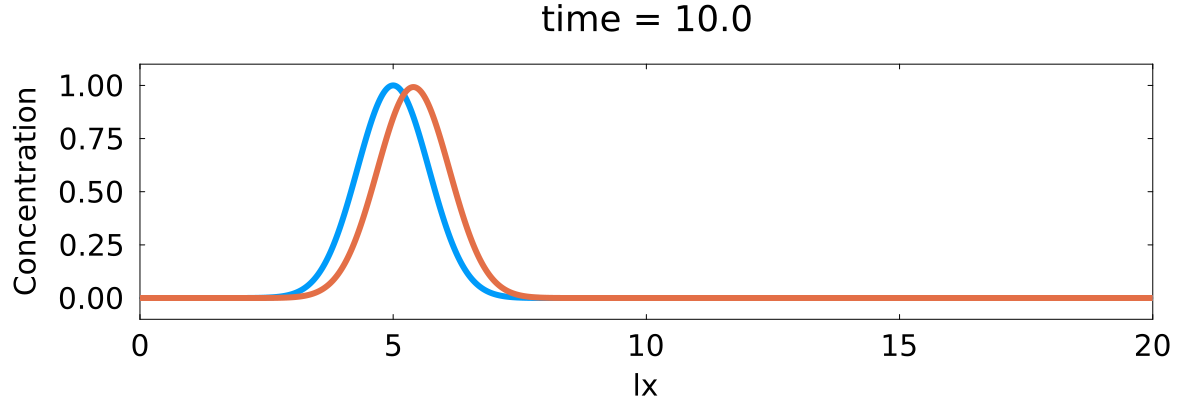

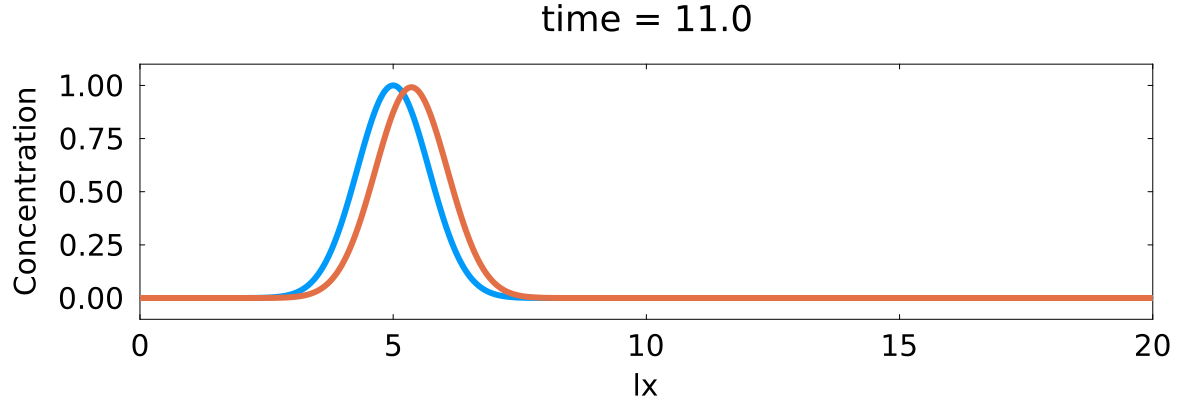

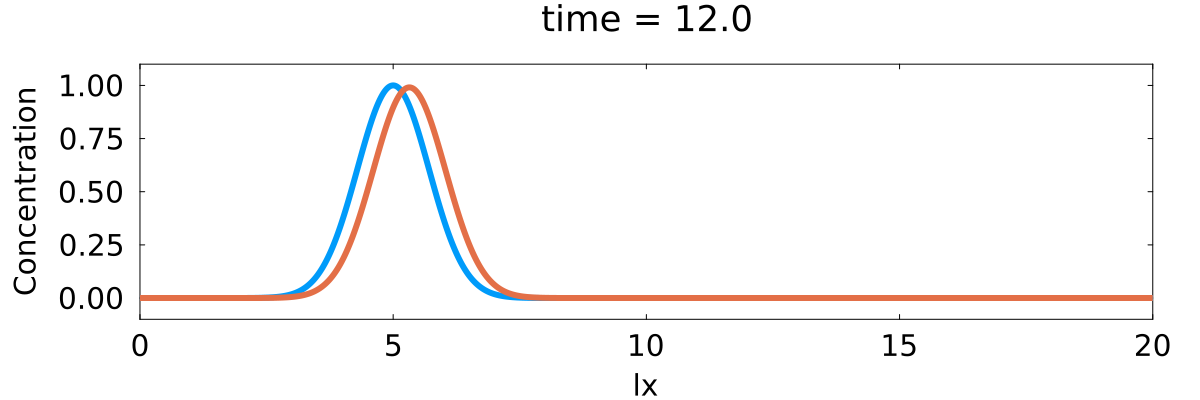

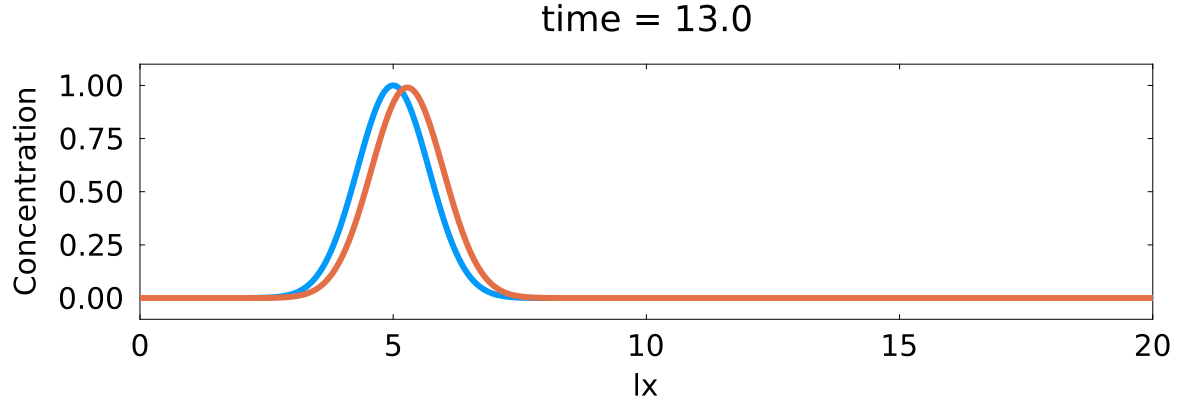

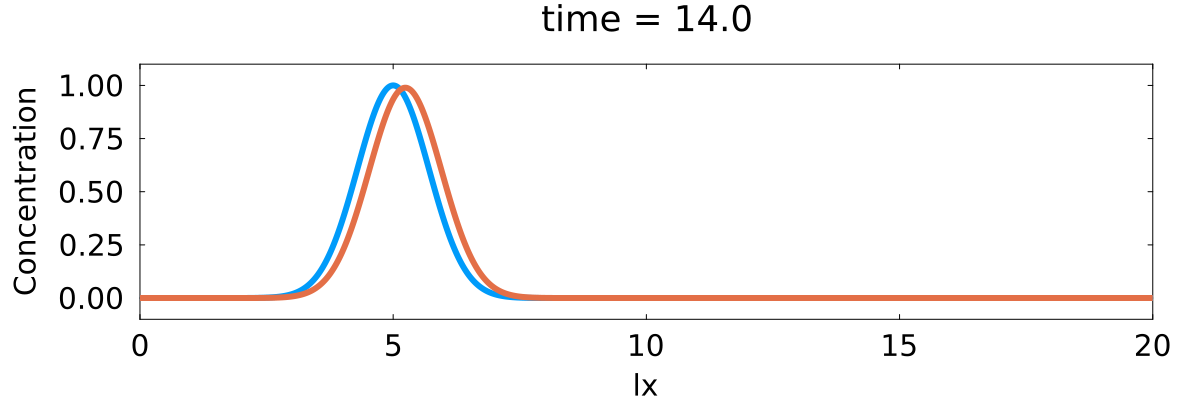

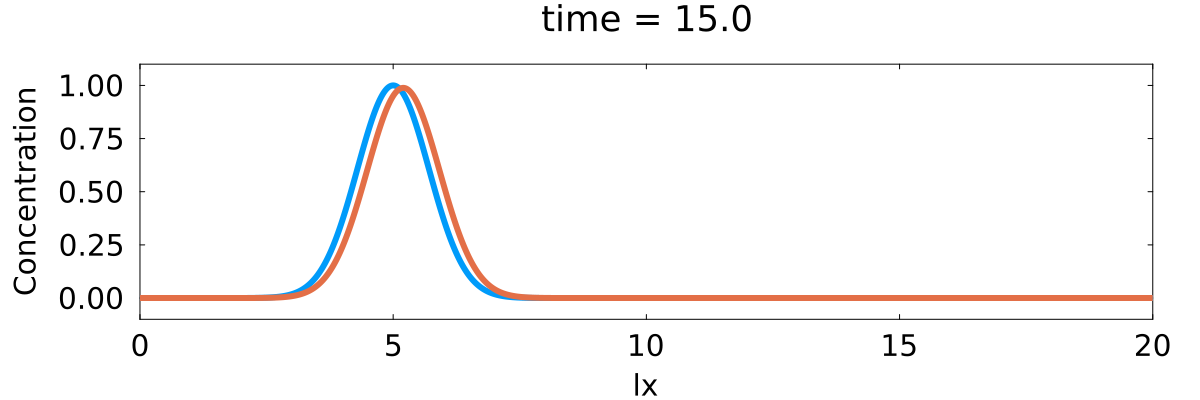

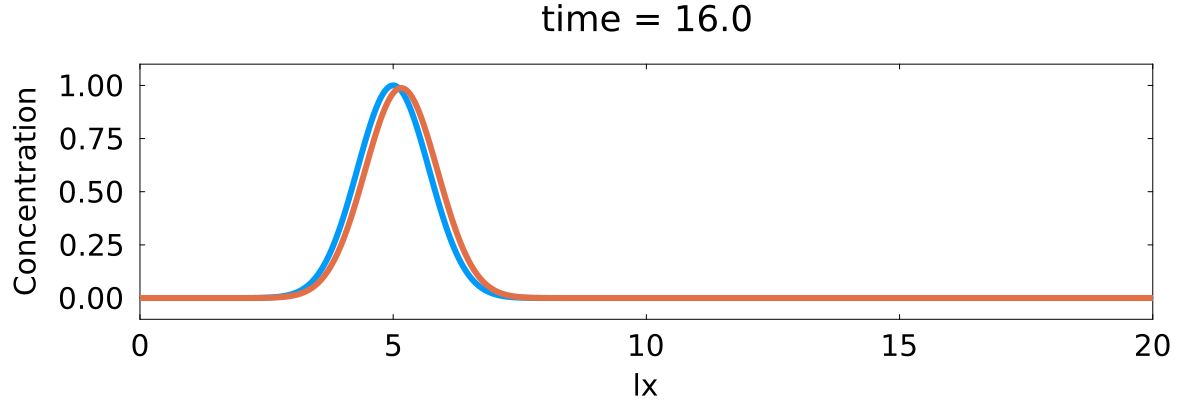

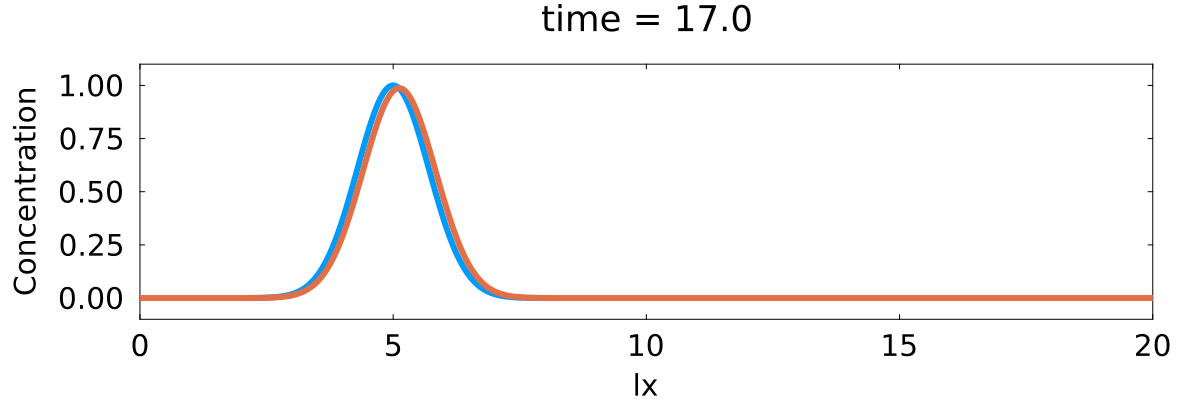

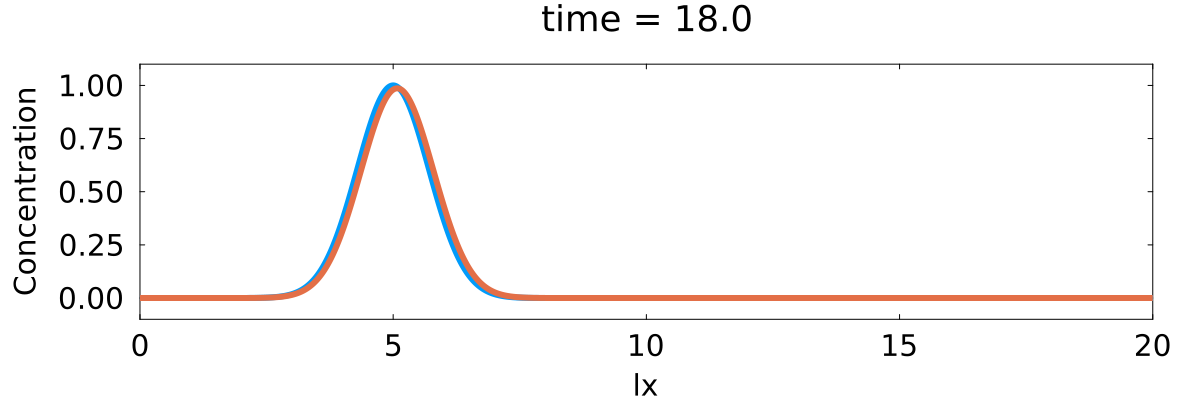

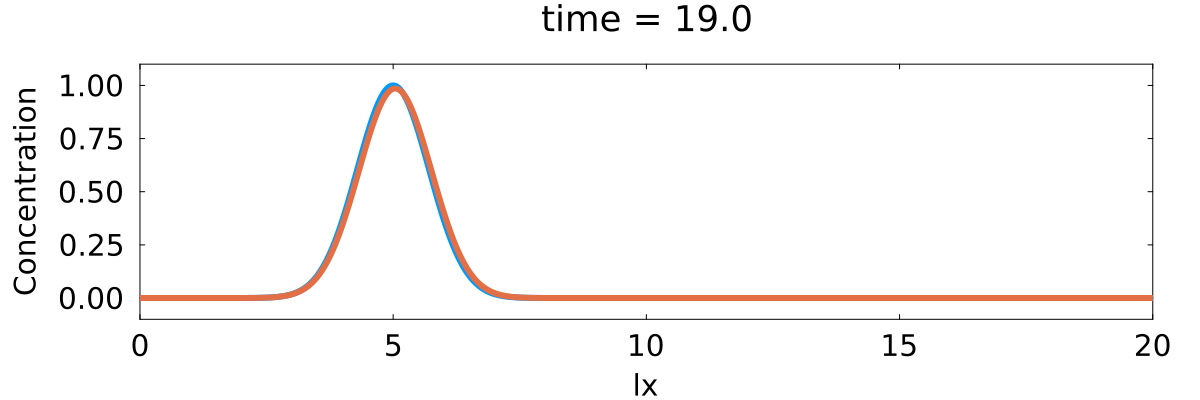

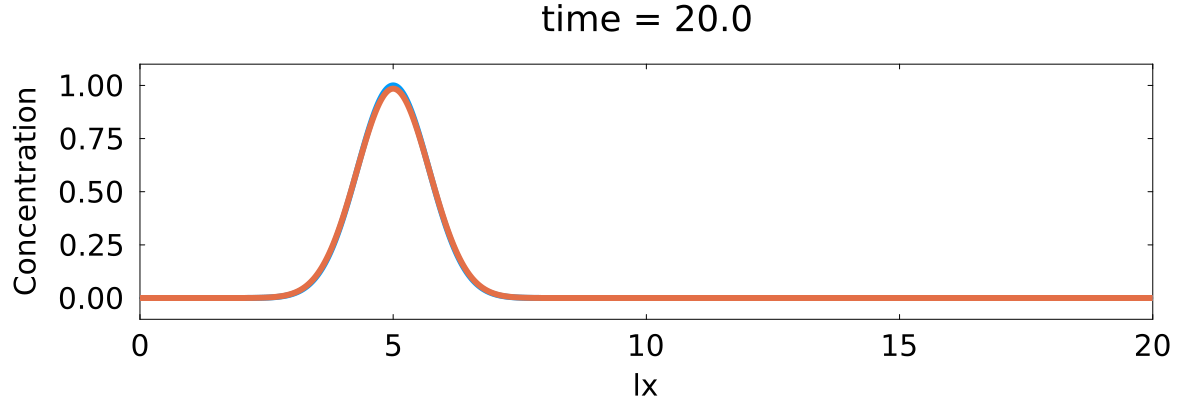

In [2]:
using Plots, Plots.Measures
default(size=(1200, 400), framestyle=:box, label=false, grid=false, margin=10mm, lw=6, labelfontsize=20, tickfontsize=20, titlefontsize=24)

@views function burger()
    # physics
    lx   = 20.0
    vx   = 1.0
    n    = 2
    
    # numerics
    nx   = 1000
    nvis = 100
    
    # derived numerics
    dx   = lx/nx
    dt   = dx/abs(vx)/2
    nt   = 2nx
    xc   = LinRange(dx/2,lx-dx/2,nx)

    C    = @. exp(-(xc - lx/4)^2)
    C_1  = copy(C)

    for it in 1:nt+1

        if vx > 0
            C[2:nx]   .-= dt * vx .* diff(C.^n)
        else
            C[1:nx-1] .-= dt * vx .* diff(C.^n)
        end
            
        if it == Int(floor(nt / 2))
            vx = -vx
        end
        
        if it % nvis == 0
            display(plot(xc, [C_1, C]; xlims=(0, lx), ylims=(-0.1, 1.1),
                 xlabel="lx", ylabel="Concentration",
                 title="time = $(round(it*dt,digits=1))"))
        end
    end
end

burger()